<a href="https://colab.research.google.com/github/Bhavninder/TOHDV/blob/main/TOHDV_PBL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
import os

In [ ]:
os.makedirs("/home/claude/output", exist_ok=True)

In [ ]:
df_monthly = pd.read_csv("india_monthly_cases.csv")
df_cfr     = pd.read_csv("cfr_by_country.csv")
df_vax     = pd.read_csv("india_vaccination_2021.csv")
df_corr    = pd.read_csv("covid_correlation_data.csv")
print("All CSVs loaded.")

All CSVs loaded.


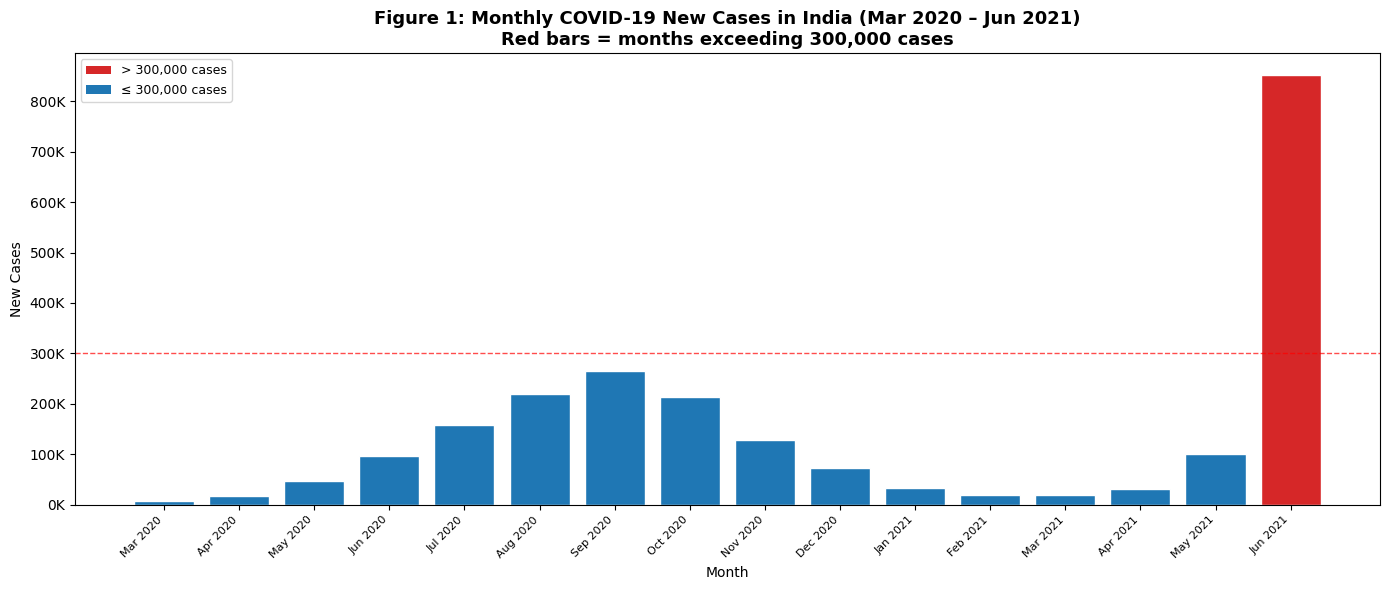

Figure 1 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#d62728" if c > 300_000 else "#1f77b4" for c in df_monthly["New_Cases"]]
ax.bar(df_monthly["Month"], df_monthly["New_Cases"], color=colors, edgecolor="white")
ax.axhline(300_000, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(handles=[Patch(facecolor="#d62728", label="> 300,000 cases"),
                   Patch(facecolor="#1f77b4", label="≤ 300,000 cases")], fontsize=9)
ax.set_title("Figure 1: Monthly COVID-19 New Cases in India (Mar 2020 – Jun 2021)\nRed bars = months exceeding 300,000 cases", fontsize=13, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("New Cases")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1000)}K"))
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()
plt.savefig("fig1_monthly_cases.png", dpi=150)
plt.close()
print("Figure 1 saved.")

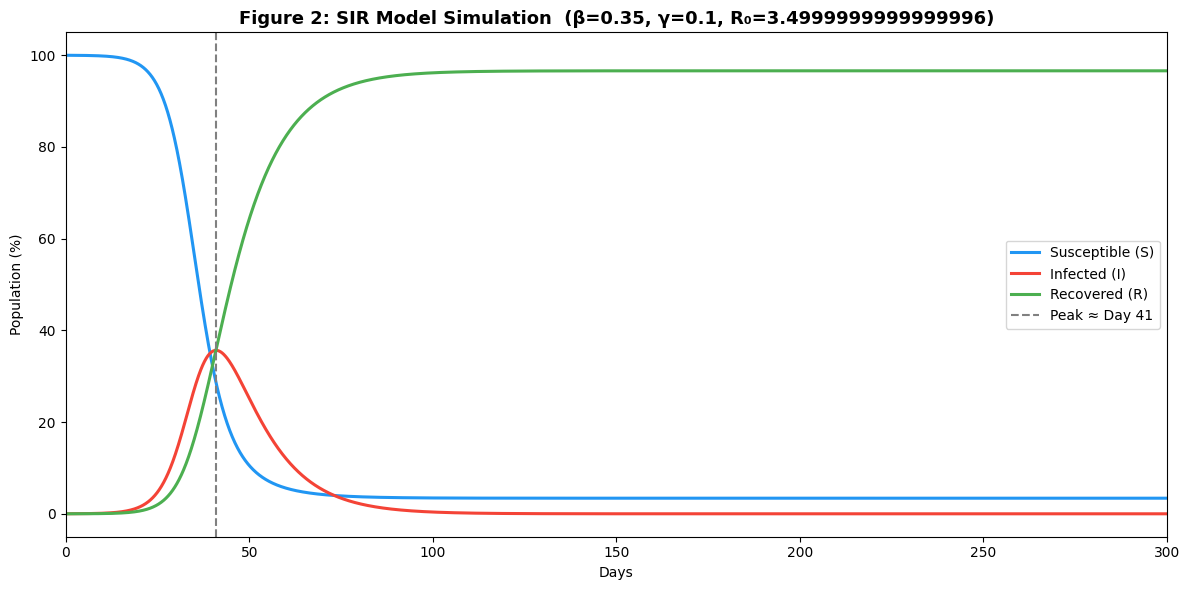

Figure 2 saved.


In [ ]:
def sir_model(y, t, beta, gamma, N):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt =  beta * S * I / N - gamma * I
    dRdt =  gamma * I
    return dSdt, dIdt, dRdt

N, beta, gamma = 1_000_000, 0.35, 0.10
t = np.linspace(0, 300, 3000)
S, I, R = odeint(sir_model, [N - 100, 100, 0], t, args=(beta, gamma, N)).T
peak_day = t[np.argmax(I)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t, S/N*100, label="Susceptible (S)", color="#2196F3", linewidth=2.2)
ax.plot(t, I/N*100, label="Infected (I)",    color="#F44336", linewidth=2.2)
ax.plot(t, R/N*100, label="Recovered (R)",   color="#4CAF50", linewidth=2.2)
ax.axvline(peak_day, color="gray", linestyle="--", linewidth=1.5, label=f"Peak ≈ Day {peak_day:.0f}")
ax.set_title(f"Figure 2: SIR Model Simulation  (β={beta}, γ={gamma}, R₀={beta/gamma})", fontsize=13, fontweight="bold")
ax.set_xlabel("Days")
ax.set_ylabel("Population (%)")
ax.legend(fontsize=10)
ax.set_xlim(0, 300)
plt.tight_layout()
plt.show()
plt.savefig("fig2_sir_model.png", dpi=150)
plt.close()
print("Figure 2 saved.")

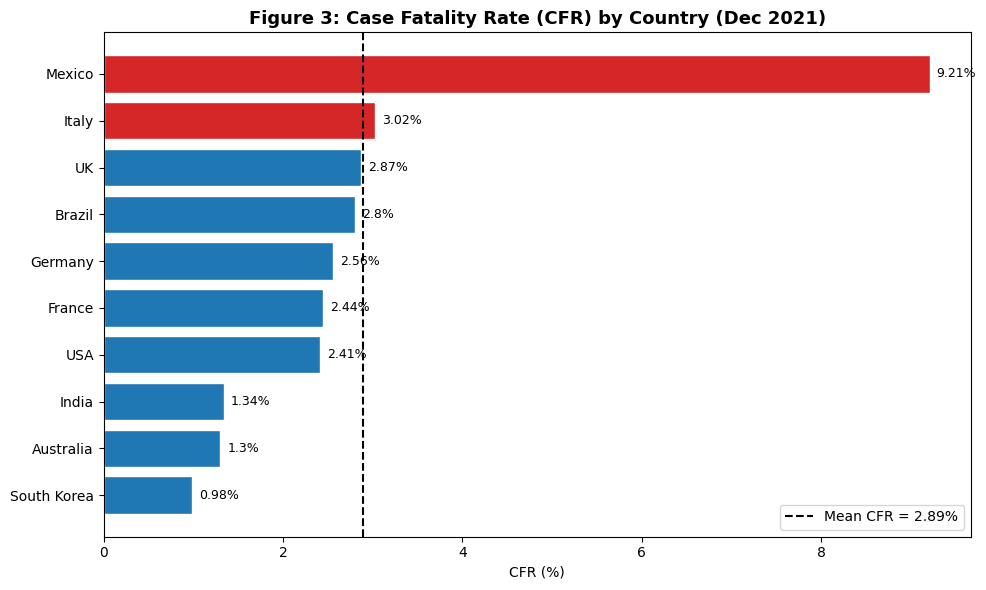

Figure 3 saved.


In [ ]:
df_cfr_s = df_cfr.sort_values("CFR", ascending=True)
mean_cfr = df_cfr["CFR"].mean()
colors   = ["#d62728" if c > mean_cfr else "#1f77b4" for c in df_cfr_s["CFR"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_cfr_s["Country"], df_cfr_s["CFR"], color=colors, edgecolor="white")
ax.axvline(mean_cfr, color="black", linestyle="--", linewidth=1.5, label=f"Mean CFR = {mean_cfr:.2f}%")
for i, v in enumerate(df_cfr_s["CFR"]):
    ax.text(v + 0.08, i, f"{v}%", va="center", fontsize=9)
ax.set_title("Figure 3: Case Fatality Rate (CFR) by Country (Dec 2021)", fontsize=13, fontweight="bold")
ax.set_xlabel("CFR (%)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
plt.savefig("fig3_cfr_comparison.png", dpi=150)
plt.close()
print("Figure 3 saved.")

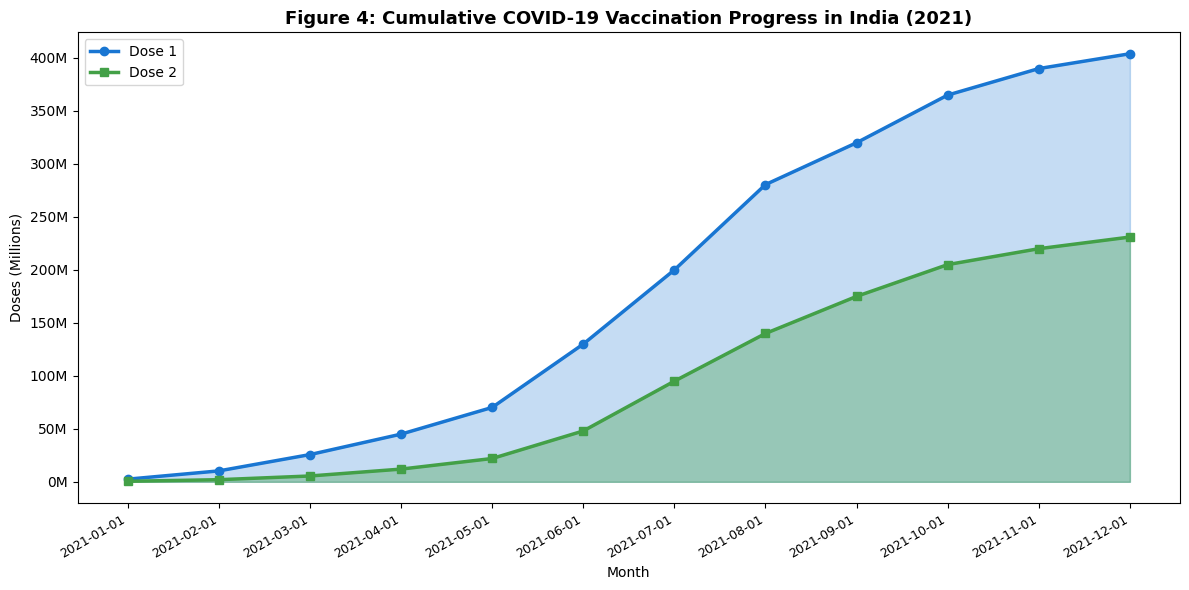

Figure 4 saved.


In [ ]:
x = range(len(df_vax))

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(x, df_vax["Dose1_Millions"], alpha=0.25, color="#1976D2")
ax.fill_between(x, df_vax["Dose2_Millions"], alpha=0.35, color="#43A047")
ax.plot(x, df_vax["Dose1_Millions"], color="#1976D2", linewidth=2.5, marker="o", markersize=6, label="Dose 1")
ax.plot(x, df_vax["Dose2_Millions"], color="#43A047", linewidth=2.5, marker="s", markersize=6, label="Dose 2")
ax.set_xticks(list(x))
ax.set_xticklabels(df_vax["Month"], rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.set_title("Figure 4: Cumulative COVID-19 Vaccination Progress in India (2021)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Doses (Millions)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
plt.savefig("fig4_vaccination.png", dpi=150)
plt.close()
print("Figure 4 saved.")



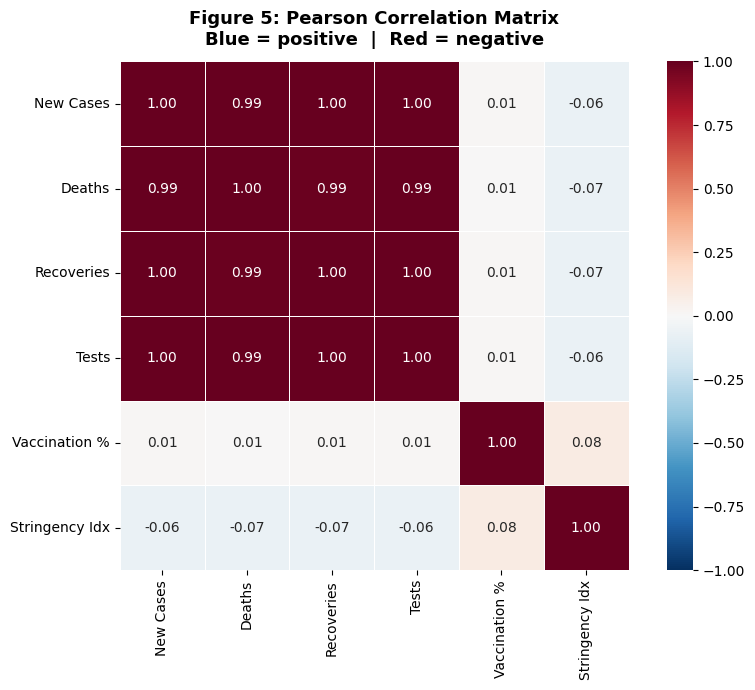

Figure 5 saved.


In [ ]:
col_labels = ["New Cases", "Deaths", "Recoveries", "Tests", "Vaccination %", "Stringency Idx"]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0,
            xticklabels=col_labels, yticklabels=col_labels,
            linewidths=0.5, square=True, ax=ax)
ax.set_title("Figure 5: Pearson Correlation Matrix\nBlue = positive  |  Red = negative", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()
plt.savefig("fig5_correlation_heatmap.png", dpi=150)
plt.close()
print("Figure 5 saved.")